In [1]:
import serial
import time
import numpy as np
import re

import socket
import os
import binascii
import struct

import matplotlib.pyplot as plt

import serial.tools.list_ports

ports = list(serial.tools.list_ports.comports())
for port in ports:
    print(port.device, port.description)

COM4 USB-Enhanced-SERIAL CH343 (COM4)
COM3 USB-Enhanced-SERIAL CH343 (COM3)


- Si5345

In [2]:
def parse_si5345_txt_file(file_path):
    result = bytearray()
    current_page = None
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        # 去除空行和注释行
        line = line.strip()
        if not line or line.startswith('#') or ',' not in line:
            continue
        
        # 分割地址和数据
        try:
            addr_data = line.split(',')
            address = int(addr_data[0].strip(), 16)
            data = int(addr_data[1].strip(), 16)
        except (ValueError, IndexError):
            # 如果解析失败，跳过这一行
            continue
        
        # 提取page和addr
        page = (address >> 8) & 0xFF
        addr = address & 0xFF
        
        # 如果遇到新的page，先写入page切换命令
        if page != current_page:
            result.extend([0x00, 0x01, 0x40, page])
            current_page = page
        
        # 写入地址和数据
        result.extend([0x00, addr, 0x40, data])
    
    # 配置002B寄存器为08，支持读取
    result.extend([0x00, 0x01, 0x40, 0x00])
    result.extend([0x00, 0x2B, 0x40, 0x08])
    return result

def config_si5345(config_data, com_port):
    """
    配置Si5345芯片
    
    参数:
    config_data: 由parse_si5345_txt_file生成的bytearray
    com_port: 串口端口号，例如 'COM3'
    """
    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF0
    ser.write(b'\xF0')

    # 发送配置数据的长度（2字节，大端序）
    length_bytes = len(config_data).to_bytes(2, byteorder='big')
    ser.write(length_bytes)
    
    # 发送配置数据
    for i in range(0, len(config_data), 2):
        # 每次发送两个字节
        bytes_to_send = config_data[i:i+2]
        ser.write(bytes_to_send)
        
        # 发送完第20个字节后等待300ms
        if i == 18:
            time.sleep(0.3)  # 等待300ms

    ser.close()

def read_si5345(page, addr, com_port):
    """
    配置Si5345芯片
    
    参数:
    config_data: 由parse_si5345_txt_file生成的bytearray
    com_port: 串口端口号，例如 'COM4'
    """
    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF1
    ser.write(b'\xF1')

    # 读取一个寄存器
    ser.write(b'\x00\x01')
    ser.write(b'\x40' + bytes([int(page, 16)]))
    ser.write(b'\x00' + bytes([int(addr, 16)]))
    ser.write(b'\x80\x00')
    result = ser.read(2).hex()
    ser.close()
    return result



- AD9253 SPI

In [3]:
def config_ad9253(adc_num, test_mode, com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF2
    ser.write(b'\xF2')

    # 发送ADC号
    ser.write(bytes([adc_num]))

    # 14bit, 0x56为125M， 0x50为20M
    sample_rate_reg = b'\x01\x00\x56'
    # sample_rate_reg = b'\x01\x00\x50'

    # 写完0x100寄存器后需要往0xFF中写0x01
    confirm_reg = b'\x00\xFF\x01'

    # test mode，0x0B: 1bit high, 0x04: checkerboard, 0x02: full scale
    if (test_mode == "none"):
        test_mode_reg = b'\x00\x0D\x00'
    elif (test_mode == "1bit high"):
        test_mode_reg = b'\x00\x0D\x0B'
    elif (test_mode == "checkerboard"):
        test_mode_reg = b'\x00\x0D\x04'
    elif (test_mode == "full scale"):
        test_mode_reg = b'\x00\x0D\x02'
    elif (test_mode == "mixed frequency"):
        test_mode_reg = b'\x00\x0D\x0C'        

    # output mode, 0x00输出为offset binary
    output_mode_reg = b'\x00\x14\x00'
    # output_mode_reg = b'\x00\x14\x01'

    # 发送配置数据的长度（2字节，大端序）
    length_bytes = len(sample_rate_reg + confirm_reg + test_mode_reg + output_mode_reg).to_bytes(2, byteorder='big')
    ser.write(length_bytes)
    
    ser.write(sample_rate_reg)
    ser.write(confirm_reg)
    ser.write(test_mode_reg)
    ser.write(output_mode_reg)

    ser.close()
import serial

def str_to_byte(value_str):
    """
    支持：
        '0xFF'
        'FF'
        '11111111'
        '255'
    返回：
        b'\xFF'
    """

    value_str = value_str.strip()

    # 二进制
    if len(value_str) == 8 and set(value_str) <= {"0", "1"}:
        value = int(value_str, 2)

    # 十六进制（带0x）
    elif value_str.lower().startswith("0x"):
        value = int(value_str, 16)

    # 十六进制（不带0x）
    elif len(value_str) == 2:
        value = int(value_str, 16)

    # 十进制
    else:
        value = int(value_str)

    if not (0 <= value <= 0xFF):
        raise ValueError("Value must be between 0 and 255.")

    return bytes([value])

def usr_test_ad9253(adc_num, D1_M, D1_L, D2_M, D2_L, com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    ser.write(b'\xF2')
    ser.write(bytes([adc_num]))

    # 14bit, 0x56为125M， 0x50为20M
    sample_rate_reg = b'\x01\x00\x56'
    # sample_rate_reg = b'\x01\x00\x50'

    # 写完0x100寄存器后需要往0xFF中写0x01
    confirm_reg = b'\x00\xFF\x01'

    D1_M_reg = b'\x00\x1A' + str_to_byte(D1_M)
    D1_L_reg = b'\x00\x19' + str_to_byte(D1_L)
    D2_M_reg = b'\x00\x1C' + str_to_byte(D2_M)
    D2_L_reg = b'\x00\x1B' + str_to_byte(D2_L)
    test_mode_reg = b'\x00\x0D\x08'

    # output mode, 0x00输出为offset binary
    output_mode_reg = b'\x00\x14\x00'

    length_bytes = len(sample_rate_reg + confirm_reg + D1_M_reg + D1_L_reg + D2_M_reg + D2_L_reg + test_mode_reg + output_mode_reg).to_bytes(2, byteorder='big')
    ser.write(length_bytes)
    ser.write(sample_rate_reg)
    ser.write(confirm_reg)
    ser.write(D1_M_reg)
    ser.write(D1_L_reg)
    ser.write(D2_M_reg)
    ser.write(D2_L_reg)
    ser.write(test_mode_reg)
    ser.write(output_mode_reg)
    ser.close()

    
def read_ad9253(adc_num, addr1, addr2, com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF3
    ser.write(b'\xF3')

    # 发送ADC号
    ser.write(bytes([adc_num]))

    # 读取一个寄存器
    ser.write(bytes([int(addr1, 16) | 0x80]) + bytes([int(addr2, 16)]))
    result = ser.read(1).hex()
    ser.close()
    print(f"adc_num: {adc_num} addr: {addr1} {addr2} result: {result}")


- AD9253 Bitslip

In [4]:
def ad9253_bitslip(adc_num, channel, com_port, time_err=1.0):
    # 通道 → 指令映射
    channel_map = {
        "cha0": 0,
        "cha1": 1,
        "chb0": 2,
        "chb1": 3,
        "chc0": 4,
        "chc1": 5,
        "chd0": 6,
        "chd1": 7,
    }

    # 通道 → 正确数据模式映射
    target_map = {
        "cha0": "10011100",
        "cha1": "10100001",
        "chb0": "10011100",
        "chb1": "10100001",
        "chc0": "10011100",
        "chc1": "10100001",
        "chd0": "10011100",
        "chd1": "10100001",
    }

    # 判断adc_num是否是0-7之间的整数
    if not isinstance(adc_num, int) or adc_num < 0 or adc_num > 7:
        raise ValueError("adc_num must be an integer between 0 and 7")
    
    if channel not in channel_map:
        raise ValueError(f"Invalid channel: {channel}")
    
    channel_num = adc_num * 8 + channel_map[channel]

    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    start_time = time.time()

    try:
        while True:
            # 超时判断
            if time.time() - start_time > time_err:
                print(f"ADC{adc_num} {channel} bitslip error.")
                return False

            # print(f"{channel} bitslipping ..")

            ser.write(b'\xF4')

            ser.write(bytes([channel_num]))

            time.sleep(0.01)

            data = ser.read(1)

            if len(data) == 0:
                print("No data received")
                return False

            result = format(data[0], '08b')
            # print(result)

            if result == target_map[channel]:
                print(f"ADC{adc_num} {channel} bitslip done.")
                return True

            time.sleep(0.1)

    finally:
        ser.close()

- Idelay

In [5]:
def idelay(com_port, adc_num, channel, delay_tap):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    channel_map = {
        "cha0": 0,
        "cha1": 1,
        "chb0": 2,
        "chb1": 3,
        "chc0": 4,
        "chc1": 5,
        "chd0": 6,
        "chd1": 7,
    }

    # 判断adc_num是否是0-7之间的整数
    if not isinstance(adc_num, int) or adc_num < 0 or adc_num > 7:
        raise ValueError("adc_num must be an integer between 0 and 7")
    
    # 判断channel是否在channel_map中
    if channel not in channel_map:
        raise ValueError(f"channel must be one of {list(channel_map.keys())}")
    
    # 判断delay_tap是否是0-31之间的整数
    if not isinstance(delay_tap, int) or delay_tap < 0 or delay_tap > 31:
        raise ValueError("delay_tap must be an integer between 0 and 31")
    
    channel_num = adc_num * 8 + channel_map[channel]

    ser.write(b'\xF5')

    ser.write(bytes([channel_num]))

    ser.write(bytes([delay_tap]))

    ser.close()
    
def find_best_delays(delays_matrix):
    delays = []

    for ch in range(delays_matrix.shape[0]):
        row = delays_matrix[ch]
        n = len(row)

        # 关键：拼接一份，处理环形
        extended = np.concatenate([row, row])

        max_len = 0
        max_start = 0

        curr_len = 0
        curr_start = 0

        for i in range(len(extended)):
            if extended[i] == 1:
                if curr_len == 0:
                    curr_start = i
                curr_len += 1

                if curr_len > max_len:
                    max_len = curr_len
                    max_start = curr_start
            else:
                curr_len = 0

        if max_len == 0:
            # 没有可用点
            delays.append(None)
            continue

        # 中点（取整数）
        center = max_start + max_len // 2

        # 映射回 0~31
        delay = center % n

        delays.append(delay)

    return delays

def ad9253_delay_cali(com_port, adc_num, time_err=1.0):
    delays_matrix = np.zeros((8, 32), dtype=int)
    channel_map = ["cha0", "cha1", "chb0", "chb1", "chc0", "chc1", "chd0", "chd1"]

    for channel in range(8):
        for delay_tap in range(32):
            idelay(com_port, adc_num, channel_map[channel], delay_tap)
            time.sleep(0.05)
            if (ad9253_bitslip(adc_num, channel_map[channel], com_port, time_err)):
                delays_matrix[channel, delay_tap] = 1
            time.sleep(0.05)
            
    print(delays_matrix)

    best_delays = find_best_delays(delays_matrix)
    print(best_delays)

    # for channel in range(8):
    #     idelay(com_port, adc_num, channel_map[channel], best_delays[channel])
    #     ad9253_bitslip(adc_num, channel_map[channel], com_port, time_err)

def ad9253_delay_cali_1ch(com_port, adc_num, channel, time_err=1.0):
    delays_matrix = np.zeros((1, 32), dtype=int)
    # channel_map = ["cha0", "cha1", "chb0", "chb1", "chc0", "chc1", "chd0", "chd1"]

    for delay_tap in range(32):
        idelay(com_port, adc_num, channel, delay_tap)
        time.sleep(0.05)
        if (ad9253_bitslip(adc_num, channel, com_port, time_err)):
            delays_matrix[0, delay_tap] = 1
        time.sleep(0.05)
            
    print(delays_matrix)

- tdc

In [6]:
def tdc_cali_1(tdc_num, ser):
    # 发送命令
    ser.write(b'\xF7')

    ser.write(bytes([tdc_num]))

    # 一次读取2字节
    data = ser.read(2)

    # 检查长度
    if len(data) != 2:
        return None

    # 拼接16bit
    value = (data[0] << 8) | data[1]

    return value


def tdc_cali(tdc_num, times, com_port):

    values = []

    # 自动打开/关闭串口
    with serial.Serial(
        com_port,
        baudrate=1000000,
        timeout=0.01,
        stopbits=2
    ) as ser:

        # 清空缓冲区
        ser.reset_input_buffer()

        # 采集数据
        for _ in range(times):

            value = tdc_cali_1(tdc_num, ser)

            # 只保留有效数据
            if value is not None:
                values.append(value)

    # 转 numpy
    values_np = np.array(values)

    # 统计信息
    mean = np.mean(values_np)
    std  = np.std(values_np)

    print(f"Samples : {len(values)}")
    print(f"Mean    : {mean:.2f}")
    print(f"Std Dev : {std:.2f}")

    # histogram统计
    hist, bin_edges = np.histogram(
        values,
        bins=np.arange(-0.5, 801.5, 1)
    )

    # 找counts最多的bin
    max_count = np.max(hist)
    max_bin   = np.argmax(hist)

    print(f"Peak bin    : {max_bin}")
    print(f"Peak counts : {max_count}")

    # -----------------------------
    # bin -> time calibration
    # -----------------------------

    samples = np.sum(hist)

    # cumulative counts
    cumulative_counts = np.cumsum(hist)

    # 转换成时间（单位ns）
    bin_time = cumulative_counts / samples * 8.0

    # bin数组
    bins = np.arange(len(hist))

    # 组合成二维数组
    cali_table = np.column_stack((bins, bin_time))

    # -----------------------------
    # 画 histogram
    # -----------------------------
    plt.figure(figsize=(10, 5))

    plt.hist(
        values,
        bins=np.arange(-0.5, 801.5, 1),
    )

    # plt.axvline(
    #     max_bin,
    #     linestyle='--',
    #     label=f'Peak Bin = {max_bin}'
    # )

    plt.xlabel("bin")
    plt.ylabel("counts")
    plt.title("TDC Calibration Histogram")

    # plt.legend()
    plt.grid(True)

    plt.show()

    # -----------------------------
    # 画 bin-time 曲线
    # -----------------------------
    plt.figure(figsize=(10, 5))

    plt.plot(bins, bin_time)

    plt.xlabel("bin")
    plt.ylabel("time (ns)")
    plt.title("TDC Bin-Time Calibration")

    plt.grid(True)

    plt.show()

    return cali_table

In [7]:
def analyze_time_diff(bin_file, tdc_table, t=1e6):

    EVENT_SIZE = 128

    times = []
    trig_list = []
    coarse_list = []
    tdc_list = []

    prev_trig_id = None

    # ----------------------------------------
    # 读取bin文件
    # ----------------------------------------
    with open(bin_file, "rb") as f:

        while True:

            event = f.read(EVENT_SIZE)

            # 文件结束
            if len(event) < EVENT_SIZE:
                break

            # ----------------------------------------
            # 解析header
            # ----------------------------------------

            # 0,1 : trig id
            trig_id = int.from_bytes(event[0:2], byteorder='big')

            # 2,3 : channel
            channel = int.from_bytes(event[2:4], byteorder='big')

            # 4~9 : coarse counter (6 bytes)
            coarse_cnt = int.from_bytes(event[4:10], byteorder='big')

            # coarse time
            t_clk = coarse_cnt * 8.0   # ns

            # 10, 11 : tdc count
            tdc_bin = int.from_bytes(event[10:12], byteorder='big')

            # 防止越界
            if tdc_bin >= len(tdc_table):

                print(
                    f"TDC BIN ERROR : "
                    f"trig_id = {trig_id}, "
                    f"tdc_bin = {tdc_bin}"
                )

                continue

            # ----------------------------------------
            # trig_id连续性检查
            # ----------------------------------------
            if prev_trig_id is not None:

                if trig_id != (prev_trig_id + 1):

                    print(
                        f"Trigger ID ERROR : "
                        f"prev = {prev_trig_id}, "
                        f"current = {trig_id}"
                    )

            prev_trig_id = trig_id

            # ----------------------------------------
            # fine time
            # ----------------------------------------
            t_tdc = tdc_table[tdc_bin][1]

            # final timestamp
            timestamp = t_clk - t_tdc

            times.append(timestamp)
            trig_list.append(trig_id)
            coarse_list.append(coarse_cnt)
            tdc_list.append(tdc_bin)

    # ----------------------------------------
    # 转numpy
    # ----------------------------------------
    times = np.array(times)
    trig_list = np.array(trig_list)
    coarse_list = np.array(coarse_list)
    tdc_list = np.array(tdc_list)

    # times = times[2:]

    if len(times) < 2:
        print("Not enough valid events")
        return None

    # ----------------------------------------
    # 相邻event时间差
    # ----------------------------------------
    time_diff = np.diff(times)

    # ----------------------------------------
    # 去掉大周期
    # delta_t = measured - ideal
    # ----------------------------------------
    delta_t = time_diff - t
    print(tdc_list)
    # ----------------------------------------
    # 异常事件检查
    # ----------------------------------------
    coarse_diff = np.diff(coarse_list)

    bad_idx = np.where(np.abs(delta_t) > 4)[0]

    print(f"\nFound {len(bad_idx)} events with |delta_t| > 4ns\n")

    for i in bad_idx:

        print(
            f"idx={i:5d}  "
            f"delta={delta_t[i]:8.3f} ns  "
            f"trig={trig_list[i]:5d}->{trig_list[i+1]:5d}  "
            f"coarse={coarse_list[i]}->{coarse_list[i+1]}  "
            f"coarse_diff={coarse_diff[i]}  "
            f"tdc={tdc_list[i]}->{tdc_list[i+1]}"
        )
    
    # ----------------------------------------
    # 统计信息
    # ----------------------------------------
    mean = np.mean(delta_t)
    std  = np.std(delta_t)

    print(f"Valid events : {len(times)}")
    print(f"Time diffs   : {len(delta_t)}")

    print(f"Delta Mean   : {mean:.4f} ns")
    print(f"Delta Std    : {std:.4f} ns")

    dmin = np.min(delta_t)
    dmax = np.max(delta_t)

    print(f"Delta Min    : {dmin:.4f} ns")
    print(f"Delta Max    : {dmax:.4f} ns")

    # ----------------------------------------
    # histogram bin
    # 0.01ns/bin
    # ----------------------------------------
    bins = np.arange(dmin, dmax + 0.01, 0.01)

    # ----------------------------------------
    # 画图
    # ----------------------------------------
    plt.figure(figsize=(10, 6))

    counts, _, _ = plt.hist(
        delta_t,
        bins=bins
    )

    # 自动贴近最高counts
    max_count = np.max(counts)

    plt.ylim(0, max_count * 1.1)

    # 禁止 scientific offset
    plt.ticklabel_format(style='plain', axis='x')
    plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)

    plt.xlabel("Delta Time (ns)")
    plt.ylabel("Counts")

    plt.title(
        f"Time Difference Histogram\n"
        f"Mean = {mean:.4f} ns, "
        f"Std = {std:.4f} ns"
    )

    plt.grid(True)

    plt.show()

    return delta_t

In [8]:
def plot_one_event(bin_file, event_num):

    EVENT_SIZE = 128
    HEADER_SIZE = 12

    with open(bin_file, "rb") as f:

        f.seek(event_num * EVENT_SIZE)

        event = f.read(EVENT_SIZE)

        if len(event) < EVENT_SIZE:
            print(f"Event {event_num} does not exist.")
            return

    # ----------------------------------------
    # header
    # ----------------------------------------
    trig_id = int.from_bytes(event[0:2], byteorder="big")
    channel = int.from_bytes(event[2:4], byteorder="big")
    coarse_cnt = int.from_bytes(event[4:10], byteorder="big")
    tdc_bin = int.from_bytes(event[10:12], byteorder="big")

    # ----------------------------------------
    # waveform
    # ----------------------------------------
    waveform = np.frombuffer(
        event[HEADER_SIZE:],
        dtype=">u2"
    )

    x = np.arange(len(waveform))

    # ----------------------------------------
    # max / min
    # ----------------------------------------
    max_idx = np.argmax(waveform)
    min_idx = np.argmin(waveform)

    max_val = waveform[max_idx]
    min_val = waveform[min_idx]

    # ----------------------------------------
    # baseline
    # 找第一个 <7300 的点
    # ----------------------------------------
    baseline = None

    below_idx = np.where(waveform < 7300)[0]

    if len(below_idx) > 0:

        first_cross = below_idx[0]

        if first_cross > 0:
            baseline = np.mean(waveform[:first_cross])
        else:
            baseline = waveform[0]

    # ----------------------------------------
    # plot
    # ----------------------------------------
    # plt.figure(figsize=(10, 6))

    plt.plot(x, waveform, marker='o')

    # 最大值
    # plt.scatter(max_idx, max_val, s=80)
    # plt.annotate(
    #     f"MAX={max_val}",
    #     xy=(max_idx, max_val),
    #     xytext=(max_idx, max_val + 50),
    #     arrowprops=dict(arrowstyle="->")
    # )

    # 最小值
    # plt.scatter(min_idx, min_val, s=80)
    # plt.annotate(
    #     f"MIN={min_val}",
    #     xy=(min_idx, min_val),
    #     xytext=(min_idx, min_val - 50),
    #     arrowprops=dict(arrowstyle="->")
    # )

    # baseline
    if baseline is not None:

        plt.axhline(
            baseline,
            linestyle="--",
            linewidth=1.5,
            label=f"Baseline = {baseline:.1f}"
        )

        plt.text(
            len(waveform) * 0.6,
            baseline,
            f"Baseline={baseline:.1f}",
            verticalalignment="bottom"
        )

    plt.xlabel("Point")
    plt.ylabel("ADC Value")

    plt.title(
        f"Event {event_num}\n"
        f"Trig={trig_id}, Ch={channel}, "
        f"Coarse={coarse_cnt}, TDC={tdc_bin}"
    )

    plt.grid(True)
    # if waveform.max() > 16000:
    #     print(trig_id)
    # return waveform.max()

    # plt.legend()
    # plt.tight_layout()
    # plt.show()

In [9]:
def analyze_time_diff_adc(bin_file, channel_num=4, t=1e6):

    EVENT_SIZE = 128
    HEAD_SIZE = 12

    times = []
    trig_list = []
    coarse_list = []

    prev_trig_id = None

    THRESHOLD = 7300

    with open(bin_file, "rb") as f:

        while True:

            event = f.read(EVENT_SIZE)

            if len(event) < EVENT_SIZE:
                break

            # ----------------------------
            # header
            # ----------------------------
            trig_id = int.from_bytes(event[0:2], byteorder="big")
            channel = int.from_bytes(event[2:4], byteorder="big")
            coarse_cnt = int.from_bytes(event[4:10], byteorder="big")

            # 只保留指定通道
            if channel != channel_num:
                continue

            # trig连续性检查
            if prev_trig_id is not None:
                if trig_id != prev_trig_id + 1:
                    print(
                        f"Trigger ID ERROR : "
                        f"{prev_trig_id} -> {trig_id}"
                    )

            prev_trig_id = trig_id

            # ----------------------------
            # waveform
            # ----------------------------
            data_bytes = event[HEAD_SIZE:]

            waveform = np.frombuffer(
                data_bytes,
                dtype=">u2"
            )

            if len(waveform) < 11:
                continue

            # ----------------------------
            # 找第一次跨过7300的位置
            # ----------------------------
            crossing_idx = None

            for i in range(len(waveform) - 1):

                va = waveform[i]
                vb = waveform[i + 1]

                if va > THRESHOLD and vb <= THRESHOLD:
                    crossing_idx = i
                    break

            if crossing_idx is None:
                continue

            VA = waveform[crossing_idx]
            VB = waveform[crossing_idx + 1]

            # ----------------------------
            # 第11个点对应 coarse_cnt
            # 即 sample index = 10
            # ----------------------------
            sample_idx_A = crossing_idx

            tA = (
                coarse_cnt * 8.0
                - (10 - sample_idx_A) * 8.0
            )

            # ----------------------------
            # 线性插值
            # ----------------------------
            frac = (VA - THRESHOLD) / (VA - VB)

            timestamp = tA + 8.0 * frac

            times.append(timestamp)
            trig_list.append(trig_id)
            coarse_list.append(coarse_cnt)

    # --------------------------------
    # numpy
    # --------------------------------
    times = np.array(times)
    trig_list = np.array(trig_list)
    coarse_list = np.array(coarse_list)

    if len(times) < 2:
        print("Not enough valid events")
        return None

    # --------------------------------
    # 时间差
    # --------------------------------
    time_diff = np.diff(times)

    delta_t = time_diff - t

    coarse_diff = np.diff(coarse_list)

    # --------------------------------
    # 异常事件
    # --------------------------------
    bad_idx = np.where(np.abs(delta_t) > 4)[0]

    print(f"\nFound {len(bad_idx)} events with |delta_t| > 4 ns\n")

    for i in bad_idx:

        print(
            f"idx={i:5d}  "
            f"delta={delta_t[i]:8.3f} ns  "
            f"trig={trig_list[i]:5d}->{trig_list[i+1]:5d}  "
            f"coarse={coarse_list[i]}->{coarse_list[i+1]}  "
            f"coarse_diff={coarse_diff[i]}"
        )

    # --------------------------------
    # 统计
    # --------------------------------
    mean = np.mean(delta_t)
    std = np.std(delta_t)

    print(f"\nValid events : {len(times)}")
    print(f"Time diffs   : {len(delta_t)}")

    print(f"Delta Mean   : {mean:.4f} ns")
    print(f"Delta Std    : {std:.4f} ns")

    dmin = np.min(delta_t)
    dmax = np.max(delta_t)

    print(f"Delta Min    : {dmin:.4f} ns")
    print(f"Delta Max    : {dmax:.4f} ns")

    # --------------------------------
    # histogram
    # --------------------------------
    bins = np.arange(dmin, dmax + 0.01, 0.01)

    plt.figure(figsize=(10, 6))

    counts, _, _ = plt.hist(
        delta_t,
        bins=bins
    )

    plt.ylim(0, np.max(counts) * 1.1)

    plt.ticklabel_format(
        style="plain",
        axis="x"
    )

    plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)

    plt.xlabel("Delta Time (ns)")
    plt.ylabel("Counts")

    plt.title(
        f"ADC Threshold Crossing Histogram\n"
        f"Channel = {channel_num}\n"
        f"Mean = {mean:.4f} ns, "
        f"Std = {std:.4f} ns"
    )

    plt.grid(True)

    plt.show()

    return delta_t

In [10]:
def monitor_trigger_continuity(
        sock,
        n=58,
        head=6,
        log_file="trigger_monitor.log",
        N_CHANNELS=32,
        RECV_EVENTS=2048):

    import time
    from collections import deque

    bytes_per_block = (n + head) * 2
    recv_size = RECV_EVENTS * bytes_per_block

    start_time = time.time()
    last_log_time = start_time

    # channel -> last raw trig_id (0~65535)
    last_raw_trig = {}

    # channel -> wrap count
    wrap_count = {}

    # channel -> real trig_id
    last_real_trig = {}

    # 最近三个event
    history = deque(maxlen=3)

    # TCP缓存
    rx_buffer = bytearray()

    # ==================================================
    # event格式化
    # ==================================================
    def format_event_hex(event_bytes):

        lines = []

        trig_id = int.from_bytes(event_bytes[0:2], "big")
        channel = int.from_bytes(event_bytes[2:4], "big")
        coarse_cnt = int.from_bytes(event_bytes[4:10], "big")

        tdc_bin = None
        if head >= 6:
            tdc_bin = int.from_bytes(event_bytes[10:12], "big")

        lines.append(
            f"TrigID={trig_id}  "
            f"Channel={channel}  "
            f"Coarse={coarse_cnt}"
            + (f"  TDC={tdc_bin}" if tdc_bin is not None else "")
        )

        lines.append("")

        for i in range(0, len(event_bytes), 16):

            chunk = event_bytes[i:i+16]

            hex_line = " ".join(
                f"{b:02X}" for b in chunk
            )

            lines.append(
                f"{i:04X}: {hex_line}"
            )

        return "\n".join(lines)

    # ==================================================
    # history输出
    # ==================================================
    def dump_history():

        lines = []

        lines.append("")
        lines.append("=" * 80)
        lines.append("EVENT HISTORY")
        lines.append("=" * 80)
        lines.append("")

        for idx, evt in enumerate(history):

            rel_idx = idx - len(history) + 1

            lines.append(
                f"History Event {rel_idx}"
            )

            lines.append(
                format_event_hex(evt)
            )

            lines.append("")

        text = "\n".join(lines)

        print(text)

        with open(log_file, "a") as f:
            f.write(text)

    # ==================================================
    # 主循环
    # ==================================================
    try:

        while True:

            # ------------------------------------------
            # 一次接收多个event
            # ------------------------------------------
            chunk = sock.recv(recv_size)

            if not chunk:

                print("Socket closed.")
                return

            rx_buffer.extend(chunk)

            # ------------------------------------------
            # 从缓存中拆event
            # ------------------------------------------
            while len(rx_buffer) >= bytes_per_block:

                event = bytes(
                    rx_buffer[:bytes_per_block]
                )

                del rx_buffer[:bytes_per_block]

                history.append(event)

                # --------------------------------------
                # header
                # --------------------------------------
                trig_id = int.from_bytes(
                    event[0:2], "big"
                )

                channel = int.from_bytes(
                    event[2:4], "big"
                )

                coarse_cnt = int.from_bytes(
                    event[4:10], "big"
                )

                # --------------------------------------
                # channel检查
                # --------------------------------------
                if not (0 <= channel < N_CHANNELS):

                    msg = (
                        "\n"
                        + "=" * 80 + "\n"
                        + "ERROR: INVALID CHANNEL\n"
                        + f"Channel={channel}\n"
                        + f"TrigID={trig_id}\n"
                        + f"Coarse={coarse_cnt}\n"
                        + "=" * 80 + "\n"
                    )

                    print(msg)

                    with open(log_file, "a") as f:
                        f.write(msg)

                    dump_history()

                    return

                # --------------------------------------
                # 第一次收到该channel
                # --------------------------------------
                if channel not in last_raw_trig:

                    last_raw_trig[channel] = trig_id
                    wrap_count[channel] = 0
                    last_real_trig[channel] = trig_id

                else:

                    prev_raw = last_raw_trig[channel]

                    # ----------------------------------
                    # 回卷检查
                    # ----------------------------------
                    if prev_raw == 65535 and trig_id == 0:

                        wrap_count[channel] += 1

                    else:

                        expected = (
                            prev_raw + 1
                        ) & 0xFFFF

                        if trig_id != expected:

                            msg = (
                                "\n"
                                + "=" * 80 + "\n"
                                + "ERROR: TRIGGER DISCONTINUITY\n"
                                + f"Channel={channel}\n"
                                + f"ExpectedRaw={expected}\n"
                                + f"ReceivedRaw={trig_id}\n"
                                + f"PreviousRaw={prev_raw}\n"
                                + f"Coarse={coarse_cnt}\n"
                                + "=" * 80 + "\n"
                            )

                            print(msg)

                            with open(log_file, "a") as f:
                                f.write(msg)

                            dump_history()

                            return

                    real_trig = (
                        wrap_count[channel] * 65536
                        + trig_id
                    )

                    last_raw_trig[channel] = trig_id
                    last_real_trig[channel] = real_trig

                # --------------------------------------
                # 每秒刷新日志
                # --------------------------------------
                now = time.time()

                if now - last_log_time >= 1.0:

                    runtime = int(
                        now - start_time
                    )

                    hours = runtime // 3600
                    minutes = (
                        runtime % 3600
                    ) // 60
                    seconds = runtime % 60

                    with open(log_file, "w") as f:

                        f.write(
                            f"Last Update: "
                            f"{time.strftime('%Y-%m-%d %H:%M:%S')}\n"
                        )

                        f.write(
                            f"Runtime: "
                            f"{hours}h "
                            f"{minutes}m "
                            f"{seconds}s\n\n"
                        )

                        f.write(
                            f"Recv Batch Size: "
                            f"{RECV_EVENTS} events\n\n"
                        )

                        for ch in range(N_CHANNELS):

                            if ch in last_real_trig:

                                f.write(
                                    f"Channel {ch:2d} : "
                                    f"TrigID = "
                                    f"{last_real_trig[ch]}\n"
                                )

                            else:

                                f.write(
                                    f"Channel {ch:2d} : "
                                    f"no data\n"
                                )

                    last_log_time = now

    except KeyboardInterrupt:

        runtime = int(
            time.time() - start_time
        )

        hours = runtime // 3600
        minutes = (
            runtime % 3600
        ) // 60
        seconds = runtime % 60

        msg = (
            "\nStopped by user (Ctrl+C)\n"
            f"Runtime: "
            f"{hours}h "
            f"{minutes}m "
            f"{seconds}s\n"
        )

        print(msg)

        with open(log_file, "a") as f:
            f.write(msg)

In [11]:
def monitor_trigger_continuity(
        sock,
        n=58,
        head=6,
        log_file="trigger_monitor.log",
        N_CHANNELS=32,
        RECV_EVENTS=2048):

    import time
    from collections import deque

    bytes_per_block = (n + head) * 2
    recv_size = RECV_EVENTS * bytes_per_block

    start_time = time.time()
    last_log_time = start_time
    last_rate_time = start_time

    total_events = 0
    last_events = 0

    # channel -> last raw trig_id (0~65535)
    last_raw_trig = {}

    # channel -> wrap count
    wrap_count = {}

    # channel -> real trig_id
    last_real_trig = {}

    # 最近三个event
    history = deque(maxlen=3)

    # TCP缓存
    rx_buffer = bytearray()

    # ==================================================
    # event格式化
    # ==================================================
    def format_event_hex(event_bytes):

        lines = []

        trig_id = int.from_bytes(event_bytes[0:2], "big")
        channel = int.from_bytes(event_bytes[2:4], "big")
        coarse_cnt = int.from_bytes(event_bytes[4:10], "big")

        tdc_bin = None
        if head >= 6:
            tdc_bin = int.from_bytes(event_bytes[10:12], "big")

        lines.append(
            f"TrigID={trig_id}  "
            f"Channel={channel}  "
            f"Coarse={coarse_cnt}"
            + (f"  TDC={tdc_bin}" if tdc_bin is not None else "")
        )

        lines.append("")

        for i in range(0, len(event_bytes), 16):

            chunk = event_bytes[i:i+16]

            hex_line = " ".join(
                f"{b:02X}" for b in chunk
            )

            lines.append(
                f"{i:04X}: {hex_line}"
            )

        return "\n".join(lines)

    # ==================================================
    # history输出
    # ==================================================
    def dump_history():

        lines = []

        lines.append("")
        lines.append("=" * 80)
        lines.append("EVENT HISTORY")
        lines.append("=" * 80)
        lines.append("")

        for idx, evt in enumerate(history):

            rel_idx = idx - len(history) + 1

            lines.append(
                f"History Event {rel_idx}"
            )

            lines.append(
                format_event_hex(evt)
            )

            lines.append("")

        text = "\n".join(lines)

        print("\n")
        print(text)

        with open(log_file, "a") as f:
            f.write(text)

    # ==================================================
    # 主循环
    # ==================================================
    try:

        while True:

            # ------------------------------------------
            # 一次接收多个event
            # ------------------------------------------
            chunk = sock.recv(recv_size)

            if not chunk:

                print("\nSocket closed.")
                return

            rx_buffer.extend(chunk)

            # ------------------------------------------
            # 从缓存中拆event
            # ------------------------------------------
            while len(rx_buffer) >= bytes_per_block:

                event = bytes(
                    rx_buffer[:bytes_per_block]
                )

                del rx_buffer[:bytes_per_block]

                history.append(event)

                total_events += 1

                # --------------------------------------
                # header
                # --------------------------------------
                trig_id = int.from_bytes(
                    event[0:2], "big"
                )

                channel = int.from_bytes(
                    event[2:4], "big"
                )

                coarse_cnt = int.from_bytes(
                    event[4:10], "big"
                )

                # --------------------------------------
                # channel检查
                # --------------------------------------
                if not (0 <= channel < N_CHANNELS):

                    msg = (
                        "\n"
                        + "=" * 80 + "\n"
                        + "ERROR: INVALID CHANNEL\n"
                        + f"Channel={channel}\n"
                        + f"TrigID={trig_id}\n"
                        + f"Coarse={coarse_cnt}\n"
                        + "=" * 80 + "\n"
                    )

                    print(msg)

                    with open(log_file, "a") as f:
                        f.write(msg)

                    dump_history()

                    return

                # --------------------------------------
                # trig连续性检查
                # --------------------------------------
                if channel not in last_raw_trig:

                    last_raw_trig[channel] = trig_id
                    wrap_count[channel] = 0
                    last_real_trig[channel] = trig_id

                else:

                    prev_raw = last_raw_trig[channel]

                    if prev_raw == 65535 and trig_id == 0:

                        wrap_count[channel] += 1

                    else:

                        expected = (
                            prev_raw + 1
                        ) & 0xFFFF

                        if trig_id != expected:

                            msg = (
                                "\n"
                                + "=" * 80 + "\n"
                                + "ERROR: TRIGGER DISCONTINUITY\n"
                                + f"Channel={channel}\n"
                                + f"ExpectedRaw={expected}\n"
                                + f"ReceivedRaw={trig_id}\n"
                                + f"PreviousRaw={prev_raw}\n"
                                + f"Coarse={coarse_cnt}\n"
                                + "=" * 80 + "\n"
                            )

                            print(msg)

                            with open(log_file, "a") as f:
                                f.write(msg)

                            dump_history()

                            return

                    real_trig = (
                        wrap_count[channel] * 65536
                        + trig_id
                    )

                    last_raw_trig[channel] = trig_id
                    last_real_trig[channel] = real_trig

                # --------------------------------------
                # 每秒刷新
                # --------------------------------------
                now = time.time()

                if now - last_log_time >= 1.0:

                    runtime = int(
                        now - start_time
                    )

                    hours = runtime // 3600
                    minutes = (
                        runtime % 3600
                    ) // 60
                    seconds = runtime % 60

                    # ------------------------------
                    # 速率统计
                    # ------------------------------
                    dt = now - last_rate_time

                    event_rate = (
                        total_events - last_events
                    ) / dt

                    data_rate_MB = (
                        event_rate * bytes_per_block
                    ) / 1024 / 1024

                    print(
                        f"\rRuntime "
                        f"{hours:02d}:{minutes:02d}:{seconds:02d} | "
                        f"Rate={event_rate:10.0f} evt/s | "
                        f"{data_rate_MB:8.2f} MB/s | "
                        f"Total={total_events}",
                        end="",
                        flush=True
                    )

                    last_events = total_events
                    last_rate_time = now

                    # ------------------------------
                    # 更新日志
                    # ------------------------------
                    with open(log_file, "w") as f:

                        f.write(
                            f"Last Update: "
                            f"{time.strftime('%Y-%m-%d %H:%M:%S')}\n"
                        )

                        f.write(
                            f"Runtime: "
                            f"{hours}h "
                            f"{minutes}m "
                            f"{seconds}s\n\n"
                        )

                        f.write(
                            f"Recv Batch Size: "
                            f"{RECV_EVENTS} events\n"
                        )

                        f.write(
                            f"Event Rate: "
                            f"{event_rate:.1f} evt/s\n"
                        )

                        f.write(
                            f"Data Rate: "
                            f"{data_rate_MB:.3f} MB/s\n"
                        )

                        f.write(
                            f"Total Events: "
                            f"{total_events}\n\n"
                        )

                        for ch in range(N_CHANNELS):

                            if ch in last_real_trig:

                                f.write(
                                    f"Channel {ch:2d} : "
                                    f"TrigID = "
                                    f"{last_real_trig[ch]}\n"
                                )

                            else:

                                f.write(
                                    f"Channel {ch:2d} : "
                                    f"no data\n"
                                )

                    last_log_time = now

    except KeyboardInterrupt:

        runtime = int(
            time.time() - start_time
        )

        hours = runtime // 3600
        minutes = (
            runtime % 3600
        ) // 60
        seconds = runtime % 60

        msg = (
            "\n\nStopped by user (Ctrl+C)\n"
            f"Runtime: "
            f"{hours}h "
            f"{minutes}m "
            f"{seconds}s\n"
        )

        print(msg)

        with open(log_file, "a") as f:
            f.write(msg)

Samples : 10000
Mean    : 367.25
Std Dev : 213.93
Peak bin    : 699
Peak counts : 602


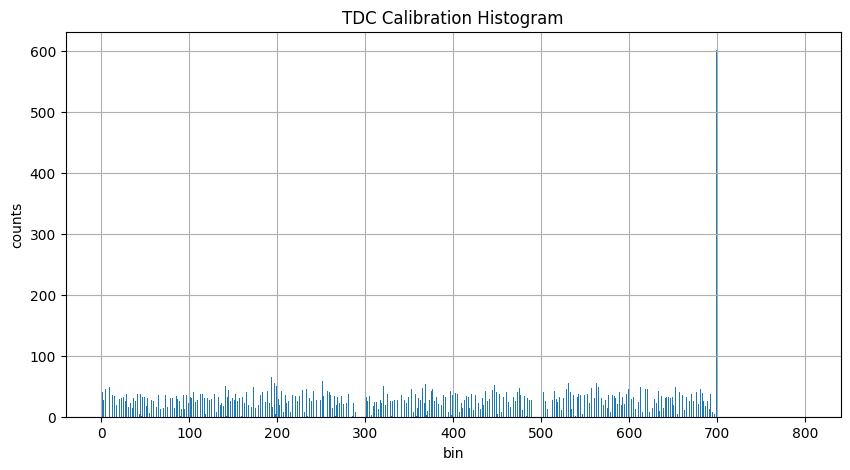

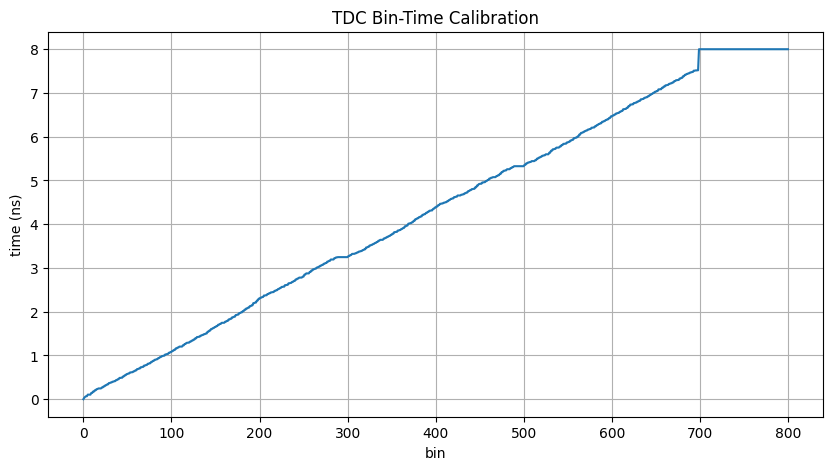

In [379]:
cali_table = tdc_cali(4, 10000, "COM4")
np.savetxt("tdc_table.txt", cali_table)

In [24]:
print(cali_table[500][1])

5.0


In [62]:
# adc0_delay_value = [9, 9, 9, 9, 9, 9, 9, 9]
# adc1_delay_value = [11, 11, 11, 11, 11, 11, 11, 11]
# adc2_delay_value = [7, 7, 7, 7, 7, 7, 7, 7]
# adc3_delay_value = [9, 11, 22, 10, 21, 11, 21, 12]
# adc4_delay_value = [11, 11, 11, 11, 11, 11, 11, 11]
# adc5_delay_value = [12, 12, 12, 12, 12, 12, 12, 12]
# adc6_delay_value = [11, 11, 11, 11, 11, 11, 11, 11]
# adc7_delay_value = [12, 12, 12, 12, 12, 12, 12, 12]

adc0_delay_value = [22, 21, 10, 22, 10, 10, 10, 20]
adc1_delay_value = [11, 23, 11, 23, 11, 24, 23, 24]
adc2_delay_value = [5, 5, 5, 18, 5, 18, 5, 7]
adc3_delay_value = [19, 8, 20, 21, 19, 9, 19, 23]
adc4_delay_value = [13, 25, 13, 25, 13, 24, 13, 25]
adc5_delay_value = [13, 12, 12, 12, 25, 12, 12, 12]
adc6_delay_value = [24, 23, 24, 21, 10, 24, 10, 12]
adc7_delay_value = [8, 9, 8, 8, 8, 8, 0, 7]
adc_delay_value = [adc0_delay_value, adc1_delay_value, adc2_delay_value, adc3_delay_value, adc4_delay_value, adc5_delay_value, adc6_delay_value, adc7_delay_value]

- DAC128S085

In [12]:
def config_dac128s085(dac_num, channel, voltage, com_port):
    """
    配置DAC128S085
    
    参数:
    channel: 通道选择，可以是"A", "B", "C", "D", "E", "F", "G", "H", "all", "All"
    voltage: 电压值，范围0-3.3V
    com_port: 串口端口号，例如 'COM4'
    """

    # 判断dac_num是否是0-7之间的整数
    if not isinstance(dac_num, int) or dac_num < 0 or dac_num > 7:
        raise ValueError("dac_num must be an integer between 0 and 7")
    
    # 验证电压范围
    if voltage < 0 or voltage > 3.3:
        raise ValueError("电压值必须在0-3.3V之间")
    
    # 计算DAC码值
    D = int(voltage * 4096 / 3.3)
    
    # 确定CMD值
    # if channel.upper() == "A":
    #     cmd = 0b0000  # 0
    # elif channel.upper() == "B":
    #     cmd = 0b0001  # 1
    # elif channel.upper() == "C":
    #     cmd = 0b0010  # 2
    # elif channel.upper() == "D":
    #     cmd = 0b0011  # 3

    if channel.upper() == "A":
        cmd = 0b0011  # 0
    elif channel.upper() == "B":
        cmd = 0b0010  # 1
    elif channel.upper() == "C":
        cmd = 0b0001  # 2
    elif channel.upper() == "D":
        cmd = 0b0000  # 3

    elif channel.upper() == "ALL":
        cmd = 0b1100  # 12
    else:
        raise ValueError("不支持的通道，有效通道为: A, B, C, D, All")
    
    # 构建16位数据DB[15:0]
    # DB[15:12] = cmd, DB[11:0] = D
    db = (cmd << 12) | (D & 0xFFF)  # 确保D只取低12位
    # db >>= 1

    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    
    # 发送0xF6
    ser.write(b'\xF6')
    # 发送dac_num
    ser.write(bytes([dac_num]))
    # 配置WTM模式
    ser.write(bytes([0b10010000, 0b00000000]))
    
    ser.write(b'\xF6')
    ser.write(bytes([dac_num]))
    # 发送16位数据（大端序）
    data_bytes = db.to_bytes(2, byteorder='big')
    ser.write(data_bytes)
        
    ser.close()

def trig_random_2ch(comp_input_static, com_port):
    import random

    # 随机生成 0~31
    num1, num2 = random.sample(range(32), 2)

    # 计算 dac_num 和 channel
    dac_num1 = num1 // 4
    channel1 = num1 % 4

    dac_num2 = num2 // 4
    channel2 = num2 % 4

    print(f"随机数1: {num1}")
    print(f"dac_num1: {dac_num1}")
    print(f"channel1: {channel1}")

    print(f"随机数2: {num2}")
    print(f"dac_num2: {dac_num2}")
    print(f"channel2: {channel2}")

    for i in range(8):
        config_dac128s085(i, "All", 2.1, 'COM4')
    config_dac128s085(dac_num1, channel1, comp_input_static[dac_num1][channel1]+0.015, com_port)
    config_dac128s085(dac_num2, channel2, comp_input_static[dac_num2][channel2]+0.015, com_port)



In [580]:
trig_random_2ch(1)

随机数1: 28
dac_num1: 7
channel1: 0
随机数2: 31
dac_num2: 7
channel2: 3


- SiTCP

In [13]:
def receive_and_save_data_tcp(sock,
                              n=58, head = 6, 
                              path="E:\\data_test\\tcp_data.bin",
                              N=100):
    """
    通过TCP接收数据并按数据块写入文件（二进制）

    参数:
        sock : 已连接socket
        n    : 数据点数量
        path : 保存路径
        N    : 数据块数量
    """

    import struct

    bytes_per_block = (n + head) * 2

    with open(path, 'wb') as f:

        for blk in range(N):

            block = b''

            # -----------------------
            # 接收完整数据块
            # -----------------------
            while len(block) < bytes_per_block:

                chunk = sock.recv(bytes_per_block - len(block))

                if not chunk:
                    print(f"socket关闭，已接收 {blk} 个数据块")
                    return

                block += chunk

            # -----------------------
            # 解析 header
            # -----------------------
            header = block[0:head*2]

            # -----------------------
            # 解析数据部分
            # -----------------------
            data_points_bytes = block[head*2:]

            data_points = []

            for i in range(0, len(data_points_bytes) - 1, 2):

                byte1 = data_points_bytes[i]
                byte2 = data_points_bytes[i + 1]

                byte2_6bit = byte2 >> 2

                point = (byte1 << 6) | byte2_6bit

                data_points.append(point)

            # -----------------------
            # 保存
            # -----------------------
            f.write(header)

            for point in data_points:
                f.write(struct.pack('>H', point))

    print(
        f"已通过TCP接收并保存 {N} 个数据块, "
        f"每个数据块中有 {n + head} 个16bit数据"
    )

# Test

- config si5345

In [58]:
si5345_config_data_125M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_125M.txt")
config_si5345(si5345_config_data_125M, 'COM4')

# si5345_config_data_20M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_20M.txt")
# config_si5345(si5345_config_data_20M, 'COM4')

print("si5345 reg:")
print(read_si5345("01", "1C", 'COM4'))
# time.sleep(5)

si5345 reg:
06


- config dac128s085

In [50]:
comp_input_static = np.array([[1.88, 1.88, 1.88, 1.89], [1.824, 1.823, 1.817, 1.823], [1.87, 1.88, 1.88, 1.88], [1.83, 1.83, 1.83, 1.83], 
                              [1.86, 1.87, 1.87, 1.86], [1.83, 1.83, 1.83, 1.83], [1.85, 1.85, 1.85, 1.85], [1.84, 1.84, 1.84, 1.83]])
dac_value = comp_input_static - 0.04


In [51]:
channel_map = {
    "a": 0,
    "b": 1,
    "c": 2,
    "d": 3,
}
for i in range(8):
    for j in range(4):
        config_dac128s085(i, list(channel_map.keys())[j], dac_value[i][j], 'COM4')

In [95]:
for i in range(8):
    config_dac128s085(i, "All", 3, 'COM4')

In [105]:
# config_dac128s085(1, "a", 1.850, 'COM4')
config_dac128s085(1, "all", 1.850, 'COM4')

- config adc

In [36]:
for i in range(8):
    usr_test_ad9253(
        adc_num=i,
        # D1_M="01111101",
        # D1_L="11110000",
        D1_M="0x00",
        D1_L="0x00",
        D2_M="0x00",
        D2_L="0x00",
        com_port="COM4"
    )
read_ad9253(1, "00", "1A", 'COM4')
read_ad9253(1, "00", "19", 'COM4')
read_ad9253(1, "00", "1C", 'COM4')
read_ad9253(1, "00", "1B", 'COM4')
read_ad9253(1, "00", "0D", 'COM4')

adc_num: 1 addr: 00 1A result: 00
adc_num: 1 addr: 00 19 result: 00
adc_num: 1 addr: 00 1C result: 00
adc_num: 1 addr: 00 1B result: 00
adc_num: 1 addr: 00 0D result: 08


In [335]:
config_ad9253(1, "checkerboard", "COM4")

In [59]:
for i in range(8):    
    config_ad9253(i, "mixed frequency", "COM4")
    read_ad9253(i, "00", "0D", 'COM4')

adc_num: 0 addr: 00 0D result: 0c
adc_num: 1 addr: 00 0D result: 0c
adc_num: 2 addr: 00 0D result: 0c
adc_num: 3 addr: 00 0D result: 0c
adc_num: 4 addr: 00 0D result: 0c
adc_num: 5 addr: 00 0D result: 0c
adc_num: 6 addr: 00 0D result: 0c
adc_num: 7 addr: 00 0D result: 0c


In [61]:
ad9253_delay_cali("COM4", 0, time_err=1.0)

ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip error.
ADC0 cha0 bitslip done.
ADC0 cha0 bitslip done.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip error.
ADC0 cha1 bitslip error.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip done.
ADC0 cha1 bitslip done.
ADC0 ch

In [63]:
channel_map = {
    "cha0": 0,
    "cha1": 1,
    "chb0": 2,
    "chb1": 3,
    "chc0": 4,
    "chc1": 5,
    "chd0": 6,
    "chd1": 7,
}
for i in range(8):
    for j in range(8):
        idelay("COM4", i, list(channel_map.keys())[j], adc_delay_value[i][j])
        ad9253_bitslip(i, list(channel_map.keys())[j], 'COM4', time_err=1)
# i = 1
# for j in range(8):
#     idelay("COM4", i, list(channel_map.keys())[j], adc_delay_value[i][j])
#     ad9253_bitslip(i, list(channel_map.keys())[j], 'COM4', time_err=1)

ADC0 cha0 bitslip done.
ADC0 cha1 bitslip done.
ADC0 chb0 bitslip done.
ADC0 chb1 bitslip done.
ADC0 chc0 bitslip done.
ADC0 chc1 bitslip done.
ADC0 chd0 bitslip done.
ADC0 chd1 bitslip done.
ADC1 cha0 bitslip done.
ADC1 cha1 bitslip done.
ADC1 chb0 bitslip done.
ADC1 chb1 bitslip done.
ADC1 chc0 bitslip done.
ADC1 chc1 bitslip done.
ADC1 chd0 bitslip done.
ADC1 chd1 bitslip done.
ADC2 cha0 bitslip done.
ADC2 cha1 bitslip done.
ADC2 chb0 bitslip done.
ADC2 chb1 bitslip done.
ADC2 chc0 bitslip done.
ADC2 chc1 bitslip done.
ADC2 chd0 bitslip done.
ADC2 chd1 bitslip done.
ADC3 cha0 bitslip done.
ADC3 cha1 bitslip done.
ADC3 chb0 bitslip done.
ADC3 chb1 bitslip done.
ADC3 chc0 bitslip done.
ADC3 chc1 bitslip done.
ADC3 chd0 bitslip done.
ADC3 chd1 bitslip done.
ADC4 cha0 bitslip done.
ADC4 cha1 bitslip done.
ADC4 chb0 bitslip done.
ADC4 chb1 bitslip done.
ADC4 chc0 bitslip done.
ADC4 chc1 bitslip done.
ADC4 chd0 bitslip done.
ADC4 chd1 bitslip done.
ADC5 cha0 bitslip done.
ADC5 cha1 bitsli

In [64]:
for i in range(8):    
    config_ad9253(i, "none", "COM4")
    read_ad9253(i, "00", "0D", 'COM4')

adc_num: 0 addr: 00 0D result: 00
adc_num: 1 addr: 00 0D result: 00
adc_num: 2 addr: 00 0D result: 00
adc_num: 3 addr: 00 0D result: 00
adc_num: 4 addr: 00 0D result: 00
adc_num: 5 addr: 00 0D result: 00
adc_num: 6 addr: 00 0D result: 00
adc_num: 7 addr: 00 0D result: 00


- SiTCP

In [53]:
client = socket.socket(family=socket.AF_INET, type=socket.SOCK_STREAM)
client.settimeout(5)
client.connect(('192.168.10.16', 24))
client

<socket.socket fd=2728, family=2, type=1, proto=0, laddr=('192.168.10.12', 8035), raddr=('192.168.10.16', 24)>

In [49]:
client.close()

In [37]:
monitor_trigger_continuity(
        client,
        n=58,
        head=6,
        log_file="E:\\data_test\\trigger_monitor.log",
        RECV_EVENTS=65536
)

Runtime 00:00:56 | Rate=     31993 evt/s |     3.91 MB/s | Total=1729027

Stopped by user (Ctrl+C)
Runtime: 0h 0m 56s



In [11]:
import numpy as np

def print_first_20_events(bin_file, tdc_table):

    EVENT_SIZE = 128
    times = []

    with open(bin_file, "rb") as f:

        for i in range(20):

            event = f.read(EVENT_SIZE)
            if len(event) < EVENT_SIZE:
                break

            # trig id
            trig_id = int.from_bytes(event[0:2], byteorder='big')

            # coarse counter
            coarse_cnt = int.from_bytes(event[4:10], byteorder='big')
            t_clk = coarse_cnt * 8.0  # ns

            # tdc
            tdc_bin = int.from_bytes(event[10:12], byteorder='big')

            if tdc_bin >= len(tdc_table):
                print(f"Event {i}: Invalid TDC bin = {tdc_bin}")
                continue

            t_tdc = tdc_table[tdc_bin][1]

            # timestamp
            timestamp = t_clk - t_tdc

            times.append(timestamp)

            print(
                f"Event {i:2d}: "
                f"Trig={trig_id:5d}, "
                f"Coarse={coarse_cnt:10d}, "
                f"TDC={tdc_bin:4d}, "
                f"Time={timestamp:15.3f} ns"
            )

    # 打印时间差
    print("\nAdjacent Time Differences:")
    for i in range(len(times) - 1):
        dt = times[i + 1] - times[i]
        print(
            f"Event {i:2d} -> {i+1:2d}: "
            f"{dt:12.3f} ns"
        )

In [168]:
np.savetxt("tdc_table.txt", cali_table)

In [12]:
tdc_table = np.loadtxt("C:\\Users\\lenovo\\Desktop\\Vivado Project\\Veto_32ch_tdc\\test_data\\有用的\\tdc_table.txt")
time_file = "C:\\Users\\lenovo\\Desktop\\Vivado Project\\Veto_32ch_tdc\\test_data\\有用的\\tdc_data_10000_1ms_run3.bin"

In [13]:
print_first_20_events(time_file, tdc_table)

Event  0: Trig=    0, Coarse=153268522721, TDC= 139, Time=1226148181766.498 ns
Event  1: Trig=    1, Coarse=153268647721, TDC= 107, Time=1226149181766.818 ns
Event  2: Trig=    2, Coarse=153268772721, TDC=  33, Time=1226150181767.599 ns
Event  3: Trig=    3, Coarse=153268897721, TDC=   9, Time=1226151181767.856 ns
Event  4: Trig=    4, Coarse=153269022722, TDC= 691, Time=1226152181768.521 ns
Event  5: Trig=    5, Coarse=153269147722, TDC= 631, Time=1226153181769.179 ns
Event  6: Trig=    6, Coarse=153269272722, TDC= 585, Time=1226154181769.709 ns
Event  7: Trig=    7, Coarse=153269397722, TDC= 513, Time=1226155181770.536 ns
Event  8: Trig=    8, Coarse=153269522722, TDC= 481, Time=1226156181770.743 ns
Event  9: Trig=    9, Coarse=153269647722, TDC= 429, Time=1226157181771.326 ns
Event 10: Trig=   10, Coarse=153269772722, TDC= 389, Time=1226158181771.742 ns
Event 11: Trig=   11, Coarse=153269897722, TDC= 321, Time=1226159181772.533 ns
Event 12: Trig=   12, Coarse=153270022722, TDC= 271,

[139 107  33 ... 413 367 313]

Found 0 events with |delta_t| > 4ns

Valid events : 10000
Time diffs   : 9999
Delta Mean   : 0.5511 ns
Delta Std    : 0.2121 ns
Delta Min    : 0.0000 ns
Delta Max    : 1.3711 ns


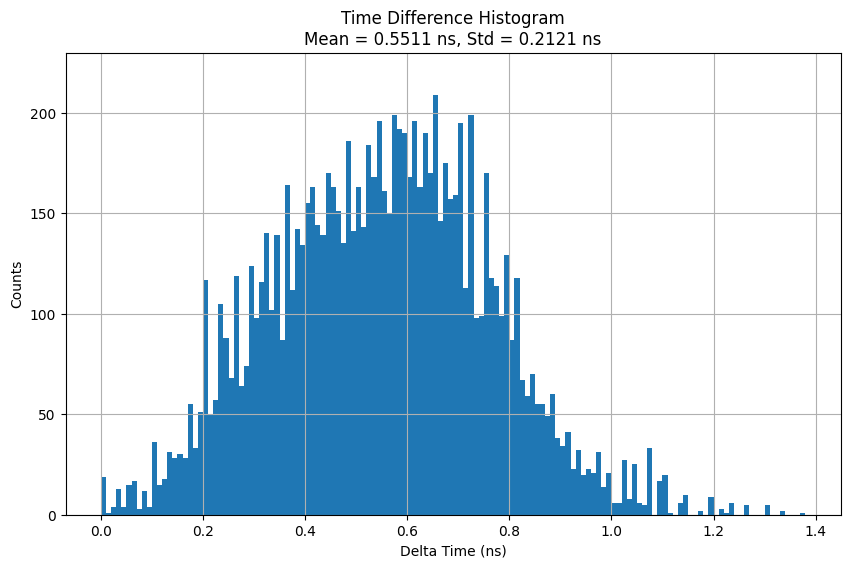

In [10]:
event_time = analyze_time_diff("C:\\Users\\lenovo\\Desktop\\Vivado Project\\Veto_32ch_tdc\\test_data\\有用的\\tdc_data_10000_1ms_run3.bin", tdc_table, t=1e6)

In [100]:
receive_and_save_data_tcp(client, N=1000)

已通过TCP接收并保存 1000 个数据块, 每个数据块中有 64 个16bit数据


In [156]:
config_dac128s085(1, "a", 1.84-0.8, 'COM4')

In [163]:
config_dac128s085(3, "b", 1.85, 'COM4')

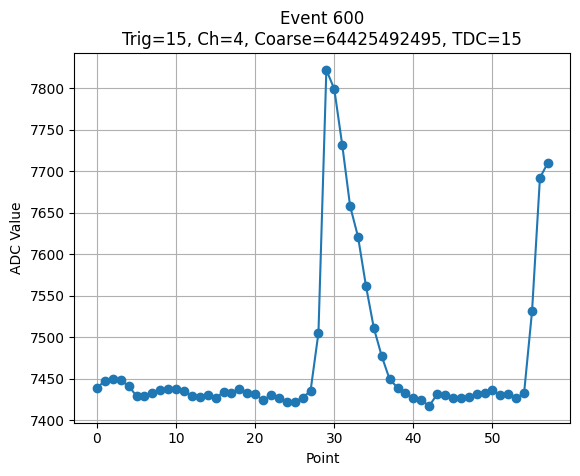

In [57]:
plot_one_event("E:\\data_test\\tcp_data.bin", event_num=600)

4108
16086


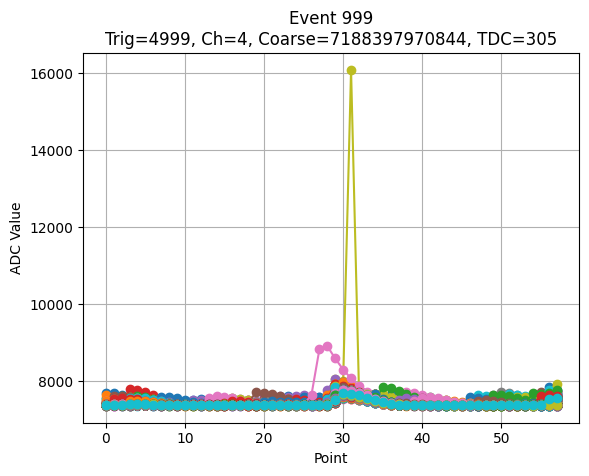

In [231]:
lis = []
for i in range(1000):
    x = plot_one_event("E:\\data_test\\tcp_data.bin", event_num=i)
    lis.append(x)
print(max(lis))

已通过TCP接收并保存 1000 个数据块, 每个数据块中有 64 个16bit数据


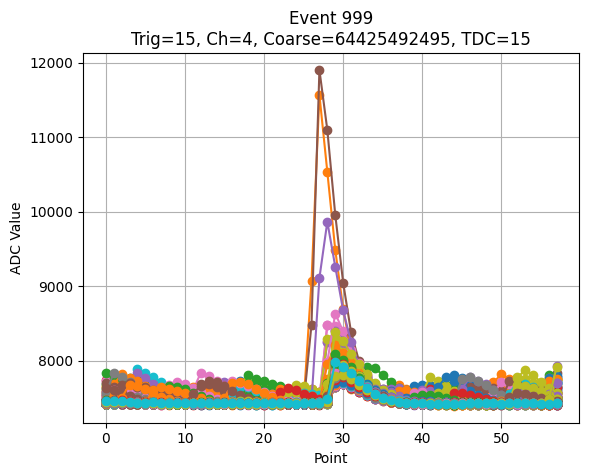

In [55]:
# config_dac128s085(1, "b", 1.84-0.04, 'COM4')

receive_and_save_data_tcp(client, N=1000)
for i in range(1000):
    plot_one_event("E:\\data_test\\tcp_data.bin", event_num=i)

In [6]:
tdc_table = np.loadtxt("C:\\Users\\lenovo\\Desktop\\Vivado Project\\Veto_32ch_tdc\\test_data\\有用的\\tdc_table.txt")

In [8]:
print(tdc_table[2])

[2.     0.0544]



Found 0 events with |delta_t| > 4 ns


Valid events : 8910
Time diffs   : 8909
Delta Mean   : 0.6168 ns
Delta Std    : 0.6336 ns
Delta Min    : -0.3335 ns
Delta Max    : 3.6177 ns


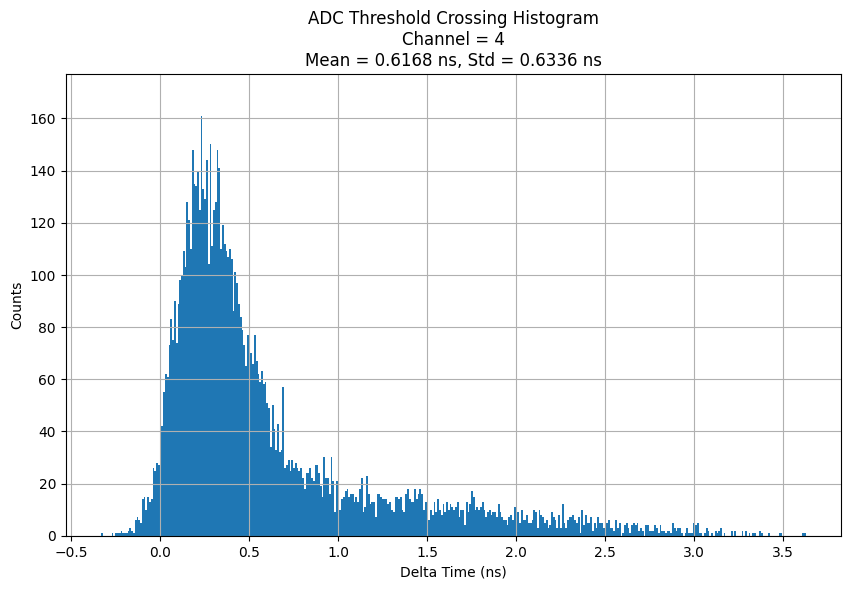

array([0.50683594, 1.10229492, 2.9206543 , ..., 0.20458984, 0.13256836,
       0.21801758])

In [545]:
analyze_time_diff_adc("E:\\data_test\\tcp_data.bin", channel_num=4, t=1e6)